# 05 · Modelo Early Fusion (mejor modelo)

**Objetivo:** Combinar imágenes y metadatos clínicos en un único modelo que aprenda las interacciones entre ambas modalidades de forma conjunta.

**Datos de entrada:** `../data/raw/hnmist_28_28_RGB.csv`, `../data/raw/HAM10000_metadata.csv`

**Resultado esperado:** Modelo guardado en `../models/mejor_modelo_early_fusion.keras` con ~80% de accuracy en test.

**Arquitectura:** Functional API con dos ramas (CNN + Dense) concatenadas antes de la capa de salida.

**Por qué Early Fusion supera a los modelos individuales:** al concatenar las representaciones de imagen y tabular antes de la clasificación final, el modelo puede aprender interacciones entre ambas fuentes (ej. una lesión pigmentada en la espalda de un hombre mayor tiene un perfil de riesgo diferente a la misma lesión en otra localización).

# Modelo 3D: Early Fusion
Ahora, vamos a utilizar la estrategia Early fusion para crear un modelo que combina los datos tabulares (el primer modelo que hicimos) con las imágenes para que el modelo tenga en cuenta además de los datos de imágenes, factores como en qué parte del cuerpo está la lesión, el sexo del paciente y su edad. En este caso, no tendríamos que importar todas las librerías que cargábamos antes, ya que vamos a reutilizar los modelos 1D y 2D 

Columnas del dataset: Index(['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004',
       'pixel0005', 'pixel0006', 'pixel0007', 'pixel0008', 'pixel0009'],
      dtype='object')


Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 28, 28,    │        896 │ input_img[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 14, 14,    │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 7, 7, 64)  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tab           │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 3, 3, 128) │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │        576 │ input_tab[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1152)      │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32)        │      1,056 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1184)      │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 1184)      │          0 │ concatenate_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 7)         │      8,295 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 103,175 (403.03 KB)

 Trainable params: 103,175 (403.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6634 - loss: 1.1159 - val_accuracy: 0.6781 - val_loss: 0.9460
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6829 - loss: 0.9395 - val_accuracy: 0.7130 - val_loss: 0.8292
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7062 - loss: 0.8427 - val_accuracy: 0.7224 - val_loss: 0.7565
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7118 - loss: 0.8081 - val_accuracy: 0.7361 - val_loss: 0.7403
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7248 - loss: 0.7728 - val_accuracy: 0.7424 - val_loss: 0.7196
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7277 - loss: 0.7476 - val_accuracy: 0.7436 - val_loss: 0.7150
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7355 - loss: 0.7249 - val_accuracy: 0.7623 - val_loss: 0.6651
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7388 - loss: 0.6951 - val_accuracy: 0.

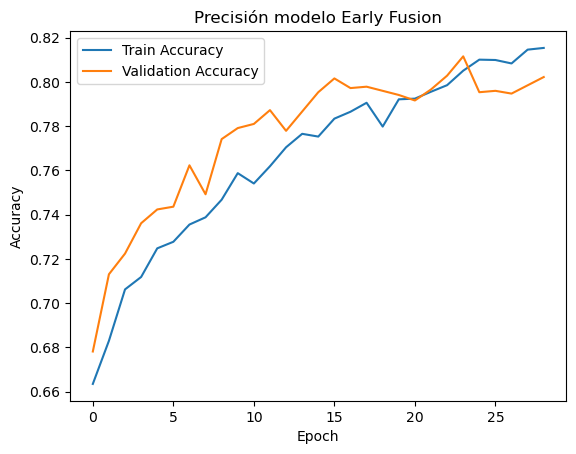

In [38]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


# Cargar datos
# CSV de imágenes
path = r"../data/raw/hnmist_28_28_RGB.csv"
df = pd.read_csv(path)
print("Columnas del dataset:", df.columns[:10])

# Metadata
metadata = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")

# Etiquetas
y = metadata['dx'].values[:len(df)]
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
num_classes = y_onehot.shape[1]

# Preprocesamiento tabular
tabular_data = metadata[['age', 'sex', 'localization']][:len(df)]
tabular_data = pd.get_dummies(tabular_data, columns=['sex', 'localization'], drop_first=True)
tabular_data['age'] = tabular_data['age'] / tabular_data['age'].max()
tabular_features = tabular_data.values.astype(np.float32)

#  Preprocesamiento imágenes
X_img = df.values.astype(np.float32).reshape(-1, 28, 28, 3)
X_img /= 255.0

X_tab = tabular_features
y_all = y_onehot


# 4 Dividir train/test

X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_img, X_tab, y_all, test_size=0.2, random_state=42, stratify=y_encoded
)

# Imputación de NaNs en tabular
X_tab_train = np.where(np.isinf(X_tab_train), np.nan, X_tab_train)
imp = SimpleImputer(strategy='median')
X_tab_train = imp.fit_transform(X_tab_train)
X_tab_test = imp.transform(X_tab_test)


#  Construcción modelo funcional Early Fusion


#  Entrada imágenes 
input_img = Input(shape=(28,28,3), name="input_img")
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)

#Entrada tabular 
input_tab = Input(shape=(X_tab_train.shape[1],), name="input_tab")
y = Dense(32, activation='relu')(input_tab)
y = Dense(32, activation='relu', kernel_regularizer=None)(y)

# Early Fusion 
combined = Concatenate()([x, y])
z = Dropout(0.5)(combined)
output = Dense(num_classes, activation='softmax')(z)

# Modelo final 
early_fusion_model = Model(inputs=[input_img, input_tab], outputs=output)
early_fusion_model.compile(optimizer=Adam(0.001),
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

early_fusion_model.summary()

# 
# Entrenamiento
# 
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = early_fusion_model.fit(
    [X_img_train, X_tab_train], y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)
 
#  Evaluación

test_loss, test_acc = early_fusion_model.evaluate([X_img_test, X_tab_test], y_test)
print(f"Test accuracy: {test_acc:.4f}")

#  graficamos resultados 
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Precisión modelo Early Fusion')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Modelo 3: Conclusiones 
En nuestro modelo 3 (Early fusion) Como vemos en la gráfica más arriba, el valor de accuracy ha estado aumentando durante todo el entrenamiento, lo cual nos deja conclusiones muy positivas para este modelo, ya que hemos llegado a alcanzar un 80% (valor más alto hasta ahora)
El modelo aprende de manera estable, y detiene su entrenamiento en epoch 23, el cual sería el punto donde detener el aprendizaje. 
Como vemos, combinar los datos tabulares con los resultados de la CNN ha conseguido que tengamos unas predicciones más fiables. Esto también nos indica que los datos tabualres pueden resultar de ayuda 
